In [6]:
!pip install -q gradio joblib

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import requests
import urllib.parse
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [8]:
query = """
SELECT
pl_name,
pl_eqt,
pl_orbper,
pl_rade,
pl_bmasse,
st_teff,
st_rad,
st_mass,
st_met,
sy_dist
FROM pscomppars
WHERE pl_eqt IS NOT NULL
"""

encoded_query = urllib.parse.quote(" ".join(query.split()))

url = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?"
    f"query={encoded_query}&format=csv"
)

df = pd.read_csv(url)

print("NASA Exoplanet dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

NASA Exoplanet dataset loaded successfully!
Dataset shape: (5836, 10)


,pl_name,pl_eqt,pl_orbper,pl_rade,pl_bmasse,st_teff,st_rad,st_mass,st_met,sy_dist
0,HD 2039 b,210.84,1120.000000,12.700000,1999.1507,5945.0,1.190,1.230,0.30,85.6922
1,HAT-P-8 b,1713.00,3.076340,15.692600,406.8224,6200.0,1.570,1.270,0.01,211.5530
2,K2-43 b,939.30,3.471149,4.510000,18.5000,3840.6,0.542,0.571,NaN,182.5360
3,Kepler-1753 b,583.00,16.004601,2.226781,5.5900,5180.0,0.769,0.860,0.00,707.6880
4,Kepler-1176 b,595.00,24.173858,2.450000,6.5700,5844.0,1.020,1.010,-0.01,864.6990


Each row represents an exoplanet and contains planetary and host-star information.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5836 entries, 0 to 5835
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pl_name    5836 non-null   object 
 1   pl_eqt     5836 non-null   float64
 2   pl_orbper  5766 non-null   float64
 3   pl_rade    5797 non-null   float64
 4   pl_bmasse  5809 non-null   float64
 5   st_teff    5825 non-null   float64
 6   st_rad     5819 non-null   float64
 7   st_mass    5829 non-null   float64
 8   st_met     5533 non-null   float64
 9   sy_dist    5814 non-null   float64
dtypes: float64(9), object(1)
memory usage: 456.1+ KB


In [13]:
df.head()

,pl_name,pl_eqt,pl_orbper,pl_rade,pl_bmasse,st_teff,st_rad,st_mass,st_met,sy_dist
0,HD 2039 b,210.84,1120.000000,12.700000,1999.1507,5945.0,1.190,1.230,0.30,85.6922
1,HAT-P-8 b,1713.00,3.076340,15.692600,406.8224,6200.0,1.570,1.270,0.01,211.5530
2,K2-43 b,939.30,3.471149,4.510000,18.5000,3840.6,0.542,0.571,NaN,182.5360
3,Kepler-1753 b,583.00,16.004601,2.226781,5.5900,5180.0,0.769,0.860,0.00,707.6880
4,Kepler-1176 b,595.00,24.173858,2.450000,6.5700,5844.0,1.020,1.010,-0.01,864.6990


In [15]:
df.describe()

,pl_eqt,pl_orbper,pl_rade,pl_bmasse,st_teff,st_rad,st_mass,st_met,sy_dist
count,5836.000000,5.766000e+03,5797.000000,5809.000000,5825.000000,5819.000000,5829.000000,5533.000000,5814.000000
mean,835.226734,7.391463e+04,5.735137,379.395503,5359.895379,1.502432,0.959872,0.019043,485.532738
std,496.784537,5.296486e+06,5.427987,1086.743739,1247.764217,3.917269,0.375224,0.187922,488.619727
min,1.480000,1.768913e-01,0.309800,0.037400,415.000000,0.011500,0.013100,-1.000000,1.301190
25%,485.645000,4.312606e+00,1.820000,4.190000,4908.000000,0.770000,0.800000,-0.080000,91.037325
50%,756.185000,1.084908e+01,2.800000,8.960000,5549.000000,0.958000,0.950000,0.020000,337.764000
75%,1093.000000,3.870427e+01,11.466787,174.805624,5904.000000,1.255867,1.100000,0.136000,768.837750
max,7777.780000,4.020000e+08,87.205870,9534.852210,40000.000000,88.475000,9.100000,0.790000,6890.000000


The dataset contains numerical astronomical measurements such as:

planetary temperature,
planetary radius,
planetary mass,
orbital period,
host-star temperature,
host-star radius,
host-star mass,
metallicity,
system distance.

These variables provide useful information for predicting the planet's equilibrium temperature.

In [18]:
 df.isnull().sum()

,0
pl_name,0
pl_eqt,0
pl_orbper,70
pl_rade,39
pl_bmasse,27
st_teff,11
st_rad,17
st_mass,7
st_met,303
sy_dist,22


Astronomical databases contain missing measurements because not every planet has every physical parameter measured.

In [21]:
print("Number of duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (5836, 10)


Duplicate observations can cause some planets to have an excessive influence during model training, so exact duplicate rows are removed.

In [22]:
numeric_columns = [
    "pl_eqt",
    "pl_orbper",
    "pl_rade",
    "pl_bmasse",
    "st_teff",
    "st_rad",
    "st_mass",
    "st_met",
    "sy_dist"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


df = df.dropna(subset=["pl_eqt"])


positive_columns = [
    "pl_eqt",
    "pl_orbper",
    "pl_rade",
    "pl_bmasse",
    "st_teff",
    "st_rad",
    "st_mass",
    "sy_dist"
]

for col in positive_columns:
    df.loc[df[col] <= 0, col] = np.nan

print("Dataset after cleaning:")
print(df.shape)

display(df.head())

Dataset after cleaning:
(5836, 10)


,pl_name,pl_eqt,pl_orbper,pl_rade,pl_bmasse,st_teff,st_rad,st_mass,st_met,sy_dist
0,HD 2039 b,210.84,1120.000000,12.700000,1999.1507,5945.0,1.190,1.230,0.30,85.6922
1,HAT-P-8 b,1713.00,3.076340,15.692600,406.8224,6200.0,1.570,1.270,0.01,211.5530
2,K2-43 b,939.30,3.471149,4.510000,18.5000,3840.6,0.542,0.571,NaN,182.5360
3,Kepler-1753 b,583.00,16.004601,2.226781,5.5900,5180.0,0.769,0.860,0.00,707.6880
4,Kepler-1176 b,595.00,24.173858,2.450000,6.5700,5844.0,1.020,1.010,-0.01,864.6990


The cleaning process:
Converts numerical fields to numeric format.
Removes rows without the target.
Converts impossible negative physical measurements into missing values.
Missing input values will later be handled using median imputation.

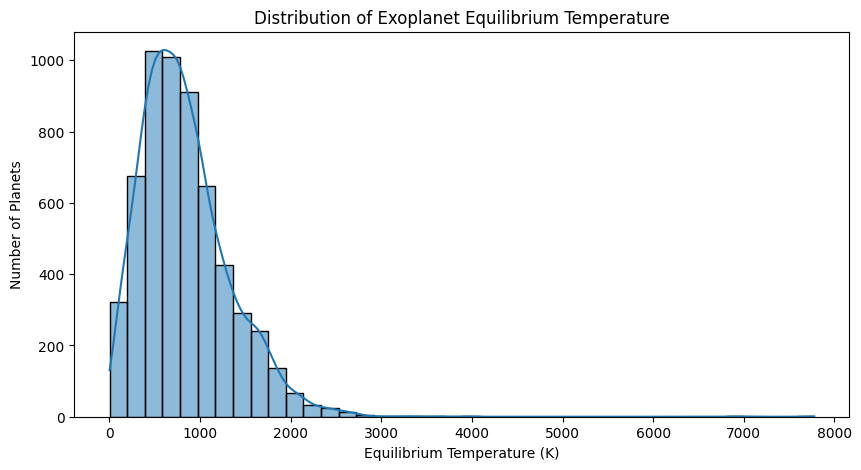

In [23]:
plt.figure(figsize=(10, 5))

sns.histplot(df["pl_eqt"].dropna(), bins=40, kde=True)

plt.title("Distribution of Exoplanet Equilibrium Temperature")
plt.xlabel("Equilibrium Temperature (K)")
plt.ylabel("Number of Planets")

plt.show()

The temperature distribution is expected to be strongly spread because exoplanets range from relatively cool planets to extremely hot planets.

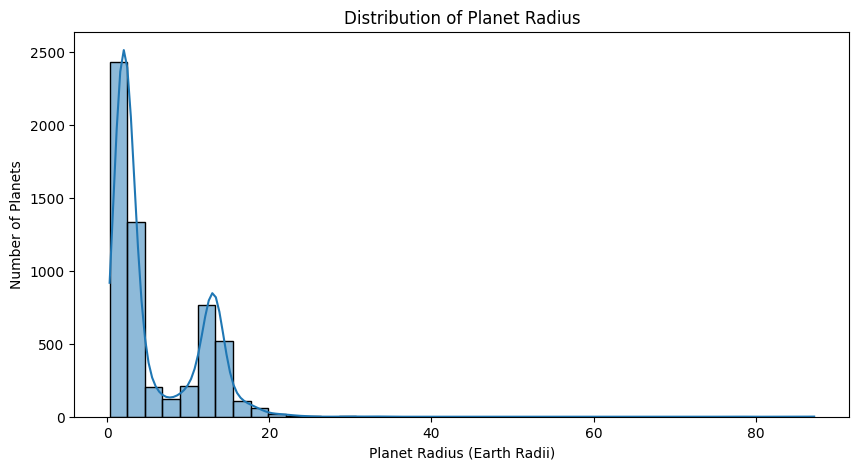

In [24]:
plt.figure(figsize=(10, 5))

sns.histplot(df["pl_rade"].dropna(), bins=40, kde=True)

plt.title("Distribution of Planet Radius")
plt.xlabel("Planet Radius (Earth Radii)")
plt.ylabel("Number of Planets")

plt.show()

Large planets can have substantially different physical characteristics from smaller planets.

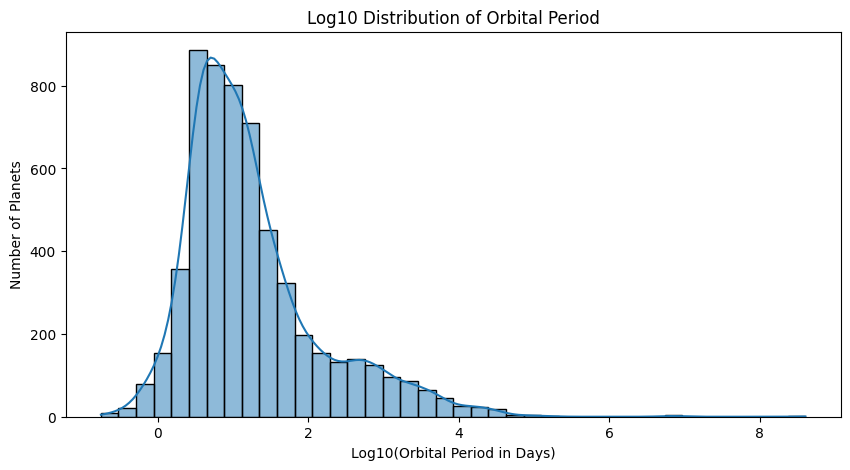

In [25]:
plt.figure(figsize=(10, 5))

sns.histplot(
    np.log10(df["pl_orbper"].dropna()),
    bins=40,
    kde=True
)

plt.title("Log10 Distribution of Orbital Period")
plt.xlabel("Log10(Orbital Period in Days)")
plt.ylabel("Number of Planets")

plt.show()

Orbital periods are highly skewed, so a logarithmic transformation makes the distribution easier to analyze.

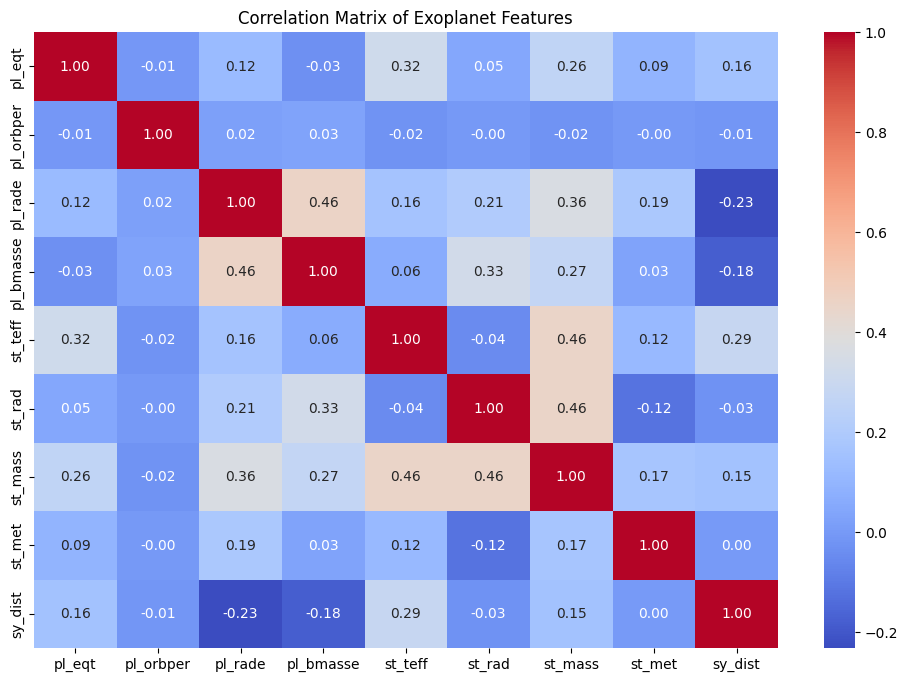

In [26]:
eda_columns = [
    "pl_eqt",
    "pl_orbper",
    "pl_rade",
    "pl_bmasse",
    "st_teff",
    "st_rad",
    "st_mass",
    "st_met",
    "sy_dist"
]

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[eda_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Exoplanet Features")

plt.show()

The correlation matrix helps identify relationships between the target and physical/orbital characteristics.

In particular, host-star temperature and orbital characteristics can contain useful information for estimating equilibrium temperature.

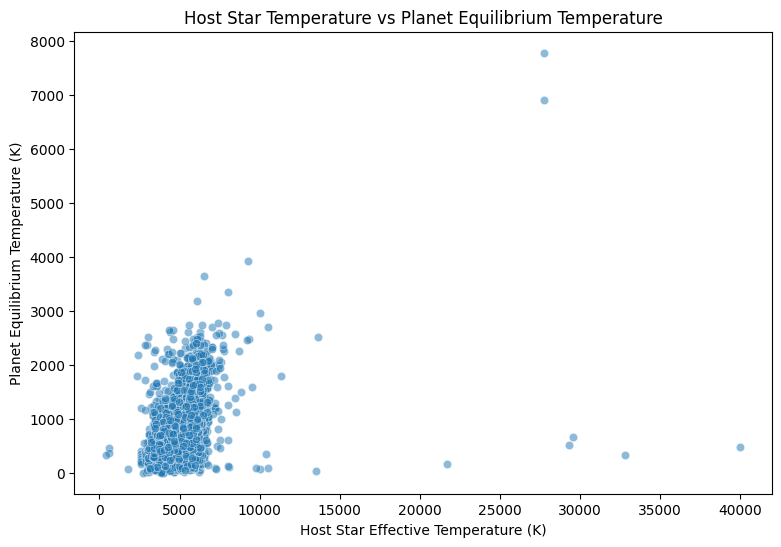

In [27]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="st_teff",
    y="pl_eqt",
    alpha=0.5
)

plt.title("Host Star Temperature vs Planet Equilibrium Temperature")
plt.xlabel("Host Star Effective Temperature (K)")
plt.ylabel("Planet Equilibrium Temperature (K)")

plt.show()

The graph allows us to examine whether planets around hotter stars tend to have higher equilibrium temperatures.

In [28]:
outlier_columns = [
    "pl_eqt",
    "pl_orbper",
    "pl_rade",
    "pl_bmasse",
    "st_teff",
    "st_rad",
    "st_mass",
    "sy_dist"
]

outlier_summary = {}

for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary[col] = count

print("Potential outliers:")
display(pd.Series(outlier_summary).sort_values(ascending=False))

Potential outliers:


,0
pl_orbper,1000
pl_bmasse,958
st_mass,410
st_rad,383
st_teff,257
pl_eqt,132
sy_dist,108
pl_rade,6


In [30]:
df["log_orbital_period"] = np.log1p(df["pl_orbper"])
df["stellar_luminosity_proxy"] = (
    (df["st_rad"] ** 2) *
    ((df["st_teff"] / 5772) ** 4)
)

print("Feature engineering completed.")

display(
    df[
        [
            "pl_orbper",
            "log_orbital_period",
            "st_rad",
            "st_teff",
            "stellar_luminosity_proxy"
        ]
    ].head()
)

Feature engineering completed.


,pl_orbper,log_orbital_period,st_rad,st_teff,stellar_luminosity_proxy
0,1120.000000,7.021976,1.190,5945.0,1.593661
1,3.076340,1.405200,1.570,6200.0,3.281412
2,3.471149,1.497645,0.542,3840.6,0.057582
3,16.004601,2.833484,0.769,5180.0,0.383589
4,24.173858,3.225806,1.020,5844.0,1.093291


In [31]:
features = [
    "pl_orbper",
    "log_orbital_period",
    "pl_rade",
    "pl_bmasse",
    "st_teff",
    "st_rad",
    "st_mass",
    "st_met",
    "sy_dist",
    "stellar_luminosity_proxy"
]

target = "pl_eqt"

X = df[features]
y = df[target]

print("Input features:")
print(features)

print("\nTarget:")
print(target)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Input features:
['pl_orbper', 'log_orbital_period', 'pl_rade', 'pl_bmasse', 'st_teff', 'st_rad', 'st_mass', 'st_met', 'sy_dist', 'stellar_luminosity_proxy']

Target:
pl_eqt

X shape: (5836, 10)
y shape: (5836,)


In [33]:
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.20,random_state=42)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4668
Testing samples: 1168


In [34]:
linear_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R2  :", linear_r2)

Linear Regression
MAE : 360.8149844291819
RMSE: 6534.731484860941
R2  : -180.9588473115684


Linear Regression provides a simple baseline.

It is useful because we can compare more advanced nonlinear models against it.

In [35]:
random_forest_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regression")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

Random Forest Regression
MAE : 67.00936942732118
RMSE: 158.67099984711146
R2  : 0.8927214734519714


Random Forest can model nonlinear relationships between planetary and stellar properties.

In [36]:
gradient_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gradient_model.fit(X_train, y_train)

gradient_pred = gradient_model.predict(X_test)

gradient_mae = mean_absolute_error(y_test, gradient_pred)
gradient_rmse = np.sqrt(mean_squared_error(y_test, gradient_pred))
gradient_r2 = r2_score(y_test, gradient_pred)

print("Gradient Boosting Regression")
print("MAE :", gradient_mae)
print("RMSE:", gradient_rmse)
print("R2  :", gradient_r2)

Gradient Boosting Regression
MAE : 75.54738741240146
RMSE: 160.62037660481883
R2  : 0.890069307740921


Gradient Boosting builds multiple decision trees sequentially.

Each new tree attempts to improve the errors made by previous trees.

In [37]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gradient_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gradient_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2,
        gradient_r2
    ]
})

results = results.sort_values("RMSE")

display(results)

,Model,MAE,RMSE,R2
1,Random Forest,67.009369,158.671000,0.892721
2,Gradient Boosting,75.547387,160.620377,0.890069
0,Linear Regression,360.814984,6534.731485,-180.958847


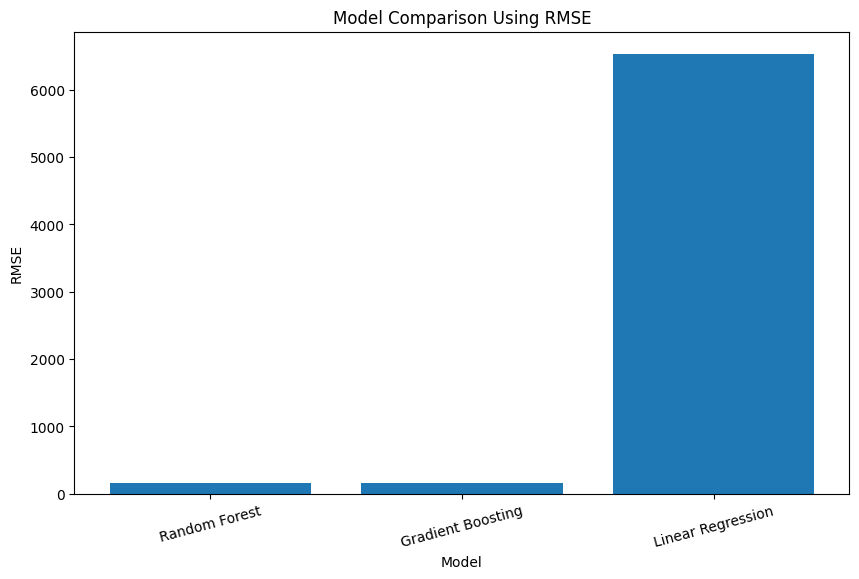

In [38]:
plt.figure(figsize=(10, 6))

plt.bar(results["Model"], results["RMSE"])

plt.title("Model Comparison Using RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=15)

plt.show()

This visualization provides a simple comparison of prediction error among the three models.

In [39]:
best_model_name = results.iloc[0]["Model"]

if best_model_name == "Linear Regression":
    final_model = linear_model
    final_predictions = linear_pred

elif best_model_name == "Random Forest":
    final_model = random_forest_model
    final_predictions = rf_pred

else:
    final_model = gradient_model
    final_predictions = gradient_pred

print("Selected final model:", best_model_name)

Selected final model: Random Forest


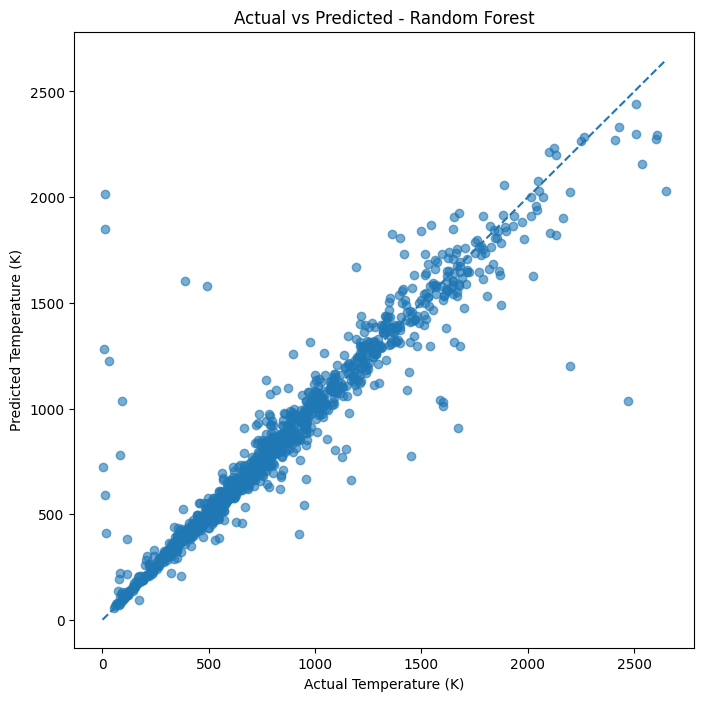

In [40]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.6
)

minimum = min(y_test.min(), final_predictions.min())
maximum = max(y_test.max(), final_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Temperature (K)")
plt.ylabel("Predicted Temperature (K)")
plt.title(f"Actual vs Predicted - {best_model_name}")

plt.show()

Points close to the diagonal line represent accurate predictions.

Large deviations from the diagonal indicate larger prediction errors.

In [41]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    final_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

cv_rmse = -cv_scores

print("5-Fold Cross-Validation RMSE:")
print(cv_rmse)

print("\nMean CV RMSE:", cv_rmse.mean())
print("Standard Deviation:", cv_rmse.std())

5-Fold Cross-Validation RMSE:
[151.1059459  139.33576334 170.15860721 139.41321669 281.74518474]

Mean CV RMSE: 176.35174357727
Standard Deviation: 53.88528600645171


Five-fold cross-validation checks whether the model performs consistently across different training/validation partitions.

In [42]:
model_data = {
    "model": final_model,
    "features": features,
    "target": target
}

joblib.dump(
    model_data,
    "exoplanet_temperature_model.pkl"
)

print("Model saved successfully!")
print("File: exoplanet_temperature_model.pkl")

Model saved successfully!
File: exoplanet_temperature_model.pkl


In [43]:
loaded_data = joblib.load("exoplanet_temperature_model.pkl")

loaded_model = loaded_data["model"]
loaded_features = loaded_data["features"]

print("Saved model loaded successfully!")
print("Features:", loaded_features)

Saved model loaded successfully!
Features: ['pl_orbper', 'log_orbital_period', 'pl_rade', 'pl_bmasse', 'st_teff', 'st_rad', 'st_mass', 'st_met', 'sy_dist', 'stellar_luminosity_proxy']


In [44]:
def predict_temperature(
    orbital_period,
    planet_radius,
    planet_mass,
    star_temperature,
    star_radius,
    star_mass,
    metallicity,
    distance
):

    log_orbital_period = np.log1p(orbital_period)

    stellar_luminosity_proxy = (
        (star_radius ** 2) *
        ((star_temperature / 5772) ** 4)
    )

    input_data = pd.DataFrame([{
        "pl_orbper": orbital_period,
        "log_orbital_period": log_orbital_period,
        "pl_rade": planet_radius,
        "pl_bmasse": planet_mass,
        "st_teff": star_temperature,
        "st_rad": star_radius,
        "st_mass": star_mass,
        "st_met": metallicity,
        "sy_dist": distance,
        "stellar_luminosity_proxy": stellar_luminosity_proxy
    }])

    prediction = loaded_model.predict(input_data)[0]

    return float(prediction)


prediction = predict_temperature(
    orbital_period=10,
    planet_radius=2,
    planet_mass=5,
    star_temperature=5500,
    star_radius=1,
    star_mass=1,
    metallicity=0,
    distance=100
)

print(f"Predicted equilibrium temperature: {prediction:.2f} K")

Predicted equilibrium temperature: 872.47 K


The function accepts astronomical characteristics of a new planet and uses the saved model to estimate its equilibrium temperature.